# REINFORCE on CartPole-v0

Credits for the notebook template go to https://goodboychan.github.io/python/reinforcement_learning/pytorch/udacity/2021/05/12/REINFORCE-CartPole.html, from which the notebook below was adapted. See https://github.com/goodboychan/goodboychan.github.io/blob/main/_notebooks/2021-05-12-REINFORCE-CartPole.ipynb on GitHub.

> In this post, We will take a hands-on-lab of Monte Carlo Policy Gradient (also known as REINFORCE) on openAI gym CartPole-v0 environment. This is the coding exercise from udacity Deep Reinforcement Learning Nanodegree.

- toc: true
- badges: true
- comments: true
- author: Chanseok Kang
- categories: [Python, Reinforcement_Learning, PyTorch, Udacity]
- image: images/CartPole-v0.gif

## REINFORCE
---
In this notebook, you will implement REINFORCE agent on OpenAI Gym's CartPole-v0 environment. For summary, The **REINFORCE** algorithm ([Williams, 1992](https://link.springer.com/content/pdf/10.1007/BF00992696.pdf)) is a monte carlo variation of policy gradient algorithm in RL. The agent collects the trajectory of an episode from current policy. Usually, this policy depends on the policy parameter which denoted as $\theta$. Actually, REINFORCE is acronym for "**RE**ward **I**ncrement = **N**onnegative **F**actor * **O**ffset **R**einforcement * **C**haracteristic **E**ligibility"

### Import the Necessary Packages

In [1]:
import gym
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (16, 10)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
torch.manual_seed(0)

import base64, io

# For visualization
from gym.wrappers.monitoring import video_recorder
from IPython.display import HTML
from IPython import display
import glob

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

### Instantiate the Environment and Agent

CartPole environment is very simple. It has discrete action space (2) and 4 dimensional state space.

### Define Policy
Unlike value-based method, the output of policy-based method is the probability of each action. It can be represented as policy. So activation function of output layer will be softmax, not ReLU.

In [3]:
env = gym.make('CartPole-v0')
env.seed(0)
# env.action_space.seed(42)  # Set the seed for action space
# np.random.seed(42)  # Set numpy seed for reproducibility

print('observation space:', env.observation_space)
print('action space:', env.action_space)

observation space: Box([-4.8000002e+00 -3.4028235e+38 -4.1887903e-01 -3.4028235e+38], [4.8000002e+00 3.4028235e+38 4.1887903e-01 3.4028235e+38], (4,), float32)
action space: Discrete(2)


/usr/local/lib/python3.11/dist-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/usr/local/lib/python3.11/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.11/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.11/dist-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` i

In [4]:
class Policy(nn.Module):
    def __init__(self, state_size=4, action_size=2, hidden_size=32):
        super(Policy, self).__init__()
        self.fc1 = nn.Linear(state_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, action_size)

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = self.fc2(x)
        # we just consider 1 dimensional probability of action
        return F.softmax(x, dim=1)

    def act(self, state):
        state = torch.from_numpy(state).float().unsqueeze(0).to(device)
        probs = self.forward(state).cpu()
        model = Categorical(probs)
        action = model.sample()
        return action.item(), model.log_prob(action)

### REINFORCE

In [5]:
# PLOT 1: vanilla REINFORCE
# --> with gradient estimator according to version 1 of the PG theorem
def reinforce(policy, optimizer, early_stop=False, n_episodes=1000, max_t=1000, gamma=1.0, print_every=100):
    scores_deque = deque(maxlen=100)
    scores = []
    for e in range(1, n_episodes):
        saved_log_probs = []
        rewards = []
        state = env.reset()
        # Collect trajectory
        for t in range(max_t):
            # Sample the action from current policy
            action, log_prob = policy.act(state)
            saved_log_probs.append(log_prob)
            state, reward, done, _ = env.step(action)
            rewards.append(reward)
            if done:
                break
        # Calculate total expected reward
        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))

        # Recalculate the total reward applying discounted factor
        discounts = [gamma ** i for i in range(len(rewards) + 1)]
        R = sum([a * b for a,b in zip(discounts, rewards)])

        # Calculate the loss
        policy_loss = []
        for log_prob in saved_log_probs:
            # Note that we are using Gradient Ascent, not Descent. So we need to calculate it with negative rewards.
            policy_loss.append(-log_prob * R)
        # After that, we concatenate whole policy loss in 0th dimension
        policy_loss = torch.cat(policy_loss).sum()

        # Backpropagation
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        if e % print_every == 0:
            print('Episode {}\tAverage Score: {:.2f}'.format(e, np.mean(scores_deque)))
        if early_stop and np.mean(scores_deque) >= 195.0:
            print('Environment solved in {:d} episodes!\tAverage Score: {:.2f}'.format(e - 100, np.mean(scores_deque)))
            break
    return scores

In [6]:
# PLOT 2: reward-to-go REINFORCE
# --> with gradient estimator according to version 2 of the PG theorem (not using Q-values, but reward to go)
def reinforce_rwd2go(policy, optimizer, early_stop=False, n_episodes=1000, max_t=1000, gamma=1.0, print_every=100):
    scores_deque = deque(maxlen=100)
    scores = []
    for e in range(1, n_episodes):
        saved_log_probs = []
        rewards = []
        state = env.reset()
        # Collect trajectory
        for t in range(max_t):
            # Sample the action from current policy
            action, log_prob = policy.act(state)
            saved_log_probs.append(log_prob)
            state, reward, done, _ = env.step(action)
            rewards.append(reward)
            if done:
                break
        # Calculate total expected reward
        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))

        # Recalculate the total reward applying discounted factor
        discounts = [gamma ** i for i in range(len(rewards) + 1)]
        rewards_to_go = [sum([discounts[j]*rewards[j+t] for j in range(len(rewards)-t) ]) for t in range(len(rewards))]

        # Calculate the loss
        policy_loss = []
        for i in range(len(saved_log_probs)):
            log_prob = saved_log_probs[i]
            G = rewards_to_go[i]
            # Note that we are using Gradient Ascent, not Descent. So we need to calculate it with negative rewards.
            policy_loss.append(-log_prob * G)
        # After that, we concatenate whole policy loss in 0th dimension
        policy_loss = torch.cat(policy_loss).sum()

        # Backpropagation
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        if e % print_every == 0:
            print('Episode {}\tAverage Score: {:.2f}'.format(e, np.mean(scores_deque)))
        if early_stop and np.mean(scores_deque) >= 195.0:
            print('Environment solved in {:d} episodes!\tAverage Score: {:.2f}'.format(e - 100, np.mean(scores_deque)))
            break
    return scores

In [7]:
# naive baseline: a large angle (among other things) is bad; so V(s) should be correlated with, e.g., -100*angle**2
def naive_baseline(state):
  angle = state[2]
  value = 100*(0.25-angle**2)
  return value

In [8]:
# PLOT 3: reward-to-go with baseline REINFORCE
# --> with gradient estimator according to version 3 of the PG theorem (not using Q-values, but reward to go)
# --> here, we consider only fixed (handcrafted) baseline functions b : S -> R; clearly, training a NN to predict V^{\pi}(s) as a baseline is also possible (and interesting!)
def reinforce_rwd2go_baseline(policy, optimizer, early_stop=False, baseline=naive_baseline, n_episodes=1000, max_t=1000, gamma=1.0, print_every=100):
    scores_deque = deque(maxlen=100)
    scores = []
    for e in range(1, n_episodes):
        saved_log_probs = []
        rewards = []
        baseline_values = []
        state = env.reset()
        # Collect trajectory
        for t in range(max_t):
            # Sample the action from current policy
            action, log_prob = policy.act(state)
            saved_log_probs.append(log_prob)
            state, reward, done, _ = env.step(action)
            rewards.append(reward)
            baseline_values.append(baseline(state))
            if done:
                break
        # Calculate total expected reward
        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))

        # Recalculate the total reward applying discounted factor
        discounts = [gamma ** i for i in range(len(rewards) + 1)]
        rewards_to_go = [sum([discounts[j]*rewards[j+t] for j in range(len(rewards)-t) ]) for t in range(len(rewards))]

        # Calculate the loss
        policy_loss = []
        for i in range(len(saved_log_probs)):
            log_prob = saved_log_probs[i]
            G_centered = rewards_to_go[i] - baseline_values[i]
            # Note that we are using Gradient Ascent, not Descent. So we need to calculate it with negative rewards.
            policy_loss.append(-log_prob * G_centered)
        # After that, we concatenate whole policy loss in 0th dimension
        policy_loss = torch.cat(policy_loss).sum()

        # Backpropagation
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        if e % print_every == 0:
            print('Episode {}\tAverage Score: {:.2f}'.format(e, np.mean(scores_deque)))
        if early_stop and np.mean(scores_deque) >= 195.0:
            print('Environment solved in {:d} episodes!\tAverage Score: {:.2f}'.format(e - 100, np.mean(scores_deque)))
            break
    return scores

### Run

In [9]:
env = gym.make('CartPole-v0')
env.seed(0)
# env.action_space.seed(0)  # Set the seed for action space
# np.random.seed(0)  # Set numpy seed for reproducibility
# PLOT 1: run vanilla REINFORCE
policy_vanilla = Policy().to(device)
optimizer_vanilla = optim.Adam(policy_vanilla.parameters(), lr=1e-2)
scores_vanilla = reinforce(policy_vanilla, optimizer_vanilla, early_stop=True, n_episodes=2000)

/usr/local/lib/python3.11/dist-packages/gym/utils/passive_env_checker.py:241: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


Episode 100	Average Score: 40.21
Episode 200	Average Score: 88.10
Episode 300	Average Score: 56.17
Episode 400	Average Score: 64.05
Episode 500	Average Score: 77.92
Episode 600	Average Score: 80.68
Episode 700	Average Score: 119.96
Environment solved in 694 episodes!	Average Score: 195.42


In [10]:
env = gym.make('CartPole-v0')
env.seed(0)
# PLOT 2: run REINFORCE with rwd2go
policy_rwd2go = Policy().to(device)
optimizer_rwd2go = optim.Adam(policy_rwd2go.parameters(), lr=1e-2)
scores_rwd2go = reinforce_rwd2go(policy_rwd2go, optimizer_rwd2go, early_stop=True, n_episodes=2000)

/usr/local/lib/python3.11/dist-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/usr/local/lib/python3.11/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.11/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.11/dist-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` i

Episode 100	Average Score: 36.46
Episode 200	Average Score: 66.01
Episode 300	Average Score: 83.76
Episode 400	Average Score: 121.08
Episode 500	Average Score: 157.89
Episode 600	Average Score: 133.02
Episode 700	Average Score: 157.06
Episode 800	Average Score: 192.90
Episode 900	Average Score: 159.38
Episode 1000	Average Score: 180.40
Episode 1100	Average Score: 153.77
Episode 1200	Average Score: 133.78
Episode 1300	Average Score: 163.21
Episode 1400	Average Score: 189.06
Episode 1500	Average Score: 176.04
Episode 1600	Average Score: 145.49
Episode 1700	Average Score: 181.41
Environment solved in 1629 episodes!	Average Score: 195.02


In [11]:
env = gym.make('CartPole-v0')
env.seed(0)
# PLOT 3: run REINFORCE with rwd2go and (naive) baseline
policy_baseline = Policy().to(device)
optimizer_baseline = optim.Adam(policy_baseline.parameters(), lr=1e-2)
scores_baseline = reinforce_rwd2go_baseline(policy_baseline, optimizer_baseline, early_stop=True, n_episodes=2000)

Episode 100	Average Score: 23.14
Episode 200	Average Score: 154.36
Episode 300	Average Score: 178.69
Episode 400	Average Score: 116.75
Episode 500	Average Score: 180.12
Episode 600	Average Score: 157.96
Episode 700	Average Score: 112.04
Episode 800	Average Score: 103.99
Episode 900	Average Score: 136.25
Episode 1000	Average Score: 122.93
Episode 1100	Average Score: 138.09
Episode 1200	Average Score: 113.39
Episode 1300	Average Score: 110.93
Episode 1400	Average Score: 110.84
Episode 1500	Average Score: 190.47
Environment solved in 1408 episodes!	Average Score: 195.08


### Plot the learning progress

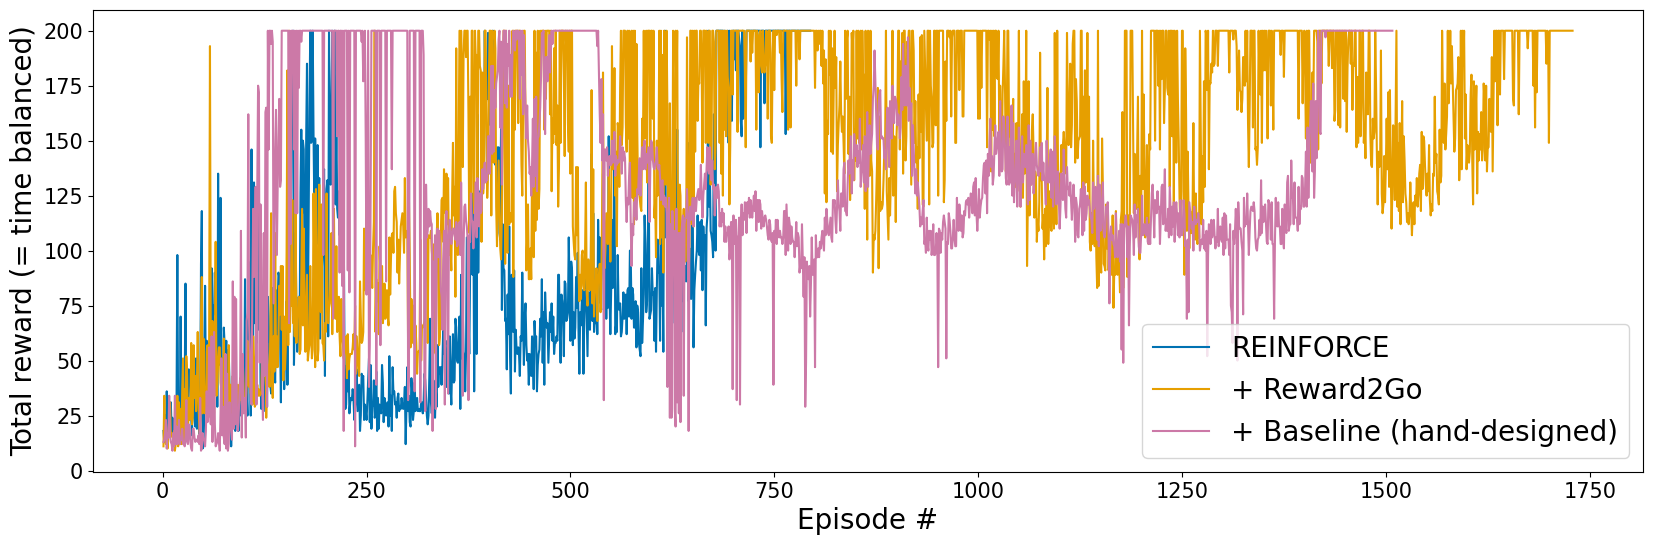

In [12]:
fig = plt.figure(figsize=(20, 6))
ax = fig.add_subplot(111)

# Using color-blind friendly hex codes
ax.plot(np.arange(1, len(scores_vanilla) + 1), scores_vanilla, color='#0072B2', label='REINFORCE')
ax.plot(np.arange(1, len(scores_rwd2go) + 1), scores_rwd2go, color='#E69F00', label='+ Reward2Go')
ax.plot(np.arange(1, len(scores_baseline) + 1), scores_baseline, color='#CC79A7', label='+ Baseline (hand-designed)')

ax.set_ylabel('Total reward (= time balanced)', fontsize=20)
ax.set_xlabel('Episode #', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.legend(fontsize=20)

plt.show()


### Animate it with Video

In [14]:
# if not done, mount google drive to store the video (only if you want to use Google Colab)
from google.colab import drive
drive.mount('drive')

Mounted at drive


In [15]:
# define path in google drive where to store (only if you want to use Google Colab)
drive_path = '/content/drive/MyDrive/Colab Notebooks/'
# if you want to run the coode and store your video locally (not Colab), write drive_path = '[your local path]' instead

In [16]:
# functions for creating the video
def show_video(env_name):
    mp4list = glob.glob(drive_path+'*.mp4')
    if len(mp4list) > 0:
        mp4 = drive_path+'{}.mp4'.format(env_name)
        video = io.open(mp4, 'r+b').read()
        encoded = base64.b64encode(video)
        display.display(HTML(data='''<video alt="test" autoplay
                loop controls style="height: 400px;">
                <source src="data:video/mp4;base64,{0}" type="video/mp4" />
             </video>'''.format(encoded.decode('ascii'))))
    else:
        print("Could not find video")

def show_video_of_model(policy, env_name):
    env = gym.make(env_name)
    vid = video_recorder.VideoRecorder(env, path=drive_path+'{}.mp4'.format(env_name))
    state = env.reset()
    done = False
    for t in range(1000):
        vid.capture_frame()
        action, _ = policy.act(state)
        next_state, reward, done, _ = env.step(action)
        state = next_state
        if done:
            break
    vid.close()
    env.close()

In [17]:
# sanity check for directory, if needed (onyl if using Colab)
#import os
#os.chdir('/content/drive/MyDrive/Colab Notebooks')
#!ls

In [18]:
# create video
policy = policy_vanilla # policy_rwd2go, policy_baseline
show_video_of_model(policy_vanilla, 'CartPole-v0')

/usr/local/lib/python3.11/dist-packages/gym/wrappers/monitoring/video_recorder.py:78: DeprecationWarning: WARN: Recording ability for environment CartPole-v0 initialized with `render_mode=None` is marked as deprecated and will be removed in the future.
  logger.deprecation(
/usr/local/lib/python3.11/dist-packages/gym/wrappers/monitoring/video_recorder.py:101: DeprecationWarning: WARN: <class 'gym.wrappers.monitoring.video_recorder.VideoRecorder'> is marked as deprecated and will be removed in the future.
  logger.deprecation(
/usr/local/lib/python3.11/dist-packages/gym/core.py:43: DeprecationWarning: WARN: The argument mode in render method is deprecated; use render_mode during environment initialization instead.
See here for more information: https://www.gymlibrary.ml/content/api/
  deprecation(
/usr/local/lib/python3.11/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_

In [19]:
# show video
show_video('CartPole-v0')